# Обучение моделей для пословной разметки. Conditional Random Fields

Для обучение используется датасет KazRusCSW-G-T.

Тегсет:
- kz – слова казахского языка.
- skz – слова казахского языка, транслитерированные на кириллице русского языка (биздин вместо “біздің”).
- ru – слова русского языка.
- other – слова из третьего языка, имена собственные, написанные на латинице и не принадлежащие к какому-либо языку (Google, Wolt), общепринятые сокращения на латинице (lol, p.s., upd), а также транслитерации с третьего языка (бро от “bro”, сейфети от “safety”).
- mixed__kz-ru, mixed__ru-kz – слова, в которых сочетаются морфемы из двух языков (казахский корень + русское окончание – mixed__kz-ru; русский корень + казахское окончание – mixed__ru-kz).
- ambig – слова, существующие в обоих языках, и имеющие одинаковое семантическое и синтаксическое значение. Например, "атом" в роли подлежащего – ambig, но в словосочетании “атом электр станциясы” (пер. атомная электростанция) –  kz. Омонимы, например, "не" и "бар" размечались также в зависимости от контекста. Данным тегом также помечались имена собственные, написанные на кириллице и имеющие одинаковое написание на обоих языках (Яндекс, Годзилла, Джордж Оруэлл).
- univ – числа, пунктуация и переносы строк, замаскированные номера и упоминания, обозначения, включающие цифры, например “гаплогруппа R1A1”.

In [ ]:
from huggingface_hub import login

login()

In [ ]:
import pandas as pd

data = pd.read_json("hf://datasets/liminovna/KazRusCSW-G-T/KazRusCSW-G-T.jsonl", lines=True)
data

,id,text,Comments,cats,entities,tokens,spans,tags
0,0,"""Близок логоть, да не укусишь"" жардың ғой хпхп...",[],[],"[[0, 1, univ], [1, 7, ru], [8, 14, ru], [14, 1...","["", Близок, логоть, ,, да, не, укусишь, "", жар...","[[0, 1], [1, 7], [8, 14], [14, 15], [16, 18], ...","[univ, ru, ru, univ, ru, ru, ru, univ, kz, kz,..."
1,1,"""Вот как выглядят лучшие дороги Жаңа Қазақстан""",[],[],"[[0, 1, univ], [1, 4, ru], [5, 8, ru], [9, 17,...","["", Вот, как, выглядят, лучшие, дороги, Жаңа, ...","[[0, 1], [1, 4], [5, 8], [9, 17], [18, 24], [2...","[univ, ru, ru, ru, ru, ru, kz, kz, univ]"
2,2,"""Высокий, красивый, статный"" ресейліктермен не...",[],[],"[[0, 1, univ], [1, 8, ru], [8, 9, univ], [10, ...","["", Высокий, ,, красивый, ,, статный, "", ресей...","[[0, 1], [1, 8], [8, 9], [10, 18], [18, 19], [...","[univ, ru, univ, ru, univ, ru, univ, kz, kz, k..."
3,3,"""Добрый день, доны! Давеча побывал у данной фе...",[],[],"[[0, 1, univ], [1, 7, ru], [8, 12, ru], [12, 1...","["", Добрый, день, ,, доны, !, Давеча, побывал,...","[[0, 1], [1, 7], [8, 12], [12, 13], [14, 18], ...","[univ, ru, ru, univ, ru, univ, ru, ru, ru, ru,..."
4,4,"""Дүние құрысын, мысығым тірі екен"" - Житель ЗК...",[],[],"[[0, 1, univ], [1, 6, kz], [7, 14, kz], [14, 1...","["", Дүние, құрысын, ,, мысығым, тірі, екен, "",...","[[0, 1], [1, 6], [7, 14], [14, 15], [16, 23], ...","[univ, kz, kz, univ, kz, kz, kz, univ, univ, r..."
...,...,...,...,...,...,...,...,...
3203,3211,Ийэ по-якутски «мама». Очень интересная паралл...,[],[],"[[0, 3, other], [4, 6, ru], [6, 7, univ], [7, ...","[Ийэ, по, -, якутски, «, мама, », ., Очень, ин...","[[0, 3], [4, 6], [6, 7], [7, 14], [15, 16], [1...","[other, ru, univ, ru, univ, ru, univ, univ, ru..."
3204,3212,А в якому році в Середній Азіїї приняли іслам?...,[],[],"[[0, 1, other], [2, 3, other], [4, 9, other], ...","[А, в, якому, році, в, Середній, Азіїї, принял...","[[0, 1], [2, 3], [4, 9], [10, 14], [15, 16], [...","[other, other, other, other, other, other, oth..."
3205,3213,Почему на русском?\nКазакша суйлөйбөйсүңөрбү,[],[],"[[0, 6, ru], [7, 9, ru], [10, 17, ru], [17, 18...","[Почему, на, русском, ?, \n, Казакша, суйлөйбө...","[[0, 6], [7, 9], [10, 17], [17, 18], [18, 20],...","[ru, ru, ru, univ, univ, other, other]"
3206,3214,"В данном случае будет Ысырап, а не Обал!\nОбал...",[],[],"[[0, 1, ru], [2, 8, ru], [9, 15, ru], [16, 21,...","[В, данном, случае, будет, Ысырап, ,, а, не, О...","[[0, 1], [2, 8], [9, 15], [16, 21], [22, 28], ...","[ru, ru, ru, ru, kz, univ, ru, ru, kz, univ, u..."


#### Сбор словарей

In [ ]:
# скачиваем словари для казахского
!wget https://raw.githubusercontent.com/taem/aspell-kk/refs/heads/master/words

!wget https://raw.githubusercontent.com/kergalym/myspell-kk/refs/heads/upstream/kk_KZ.dic
!wget https://raw.githubusercontent.com/kergalym/myspell-kk/refs/heads/upstream/kk_KZ.aff
!wget https://raw.githubusercontent.com/kergalym/myspell-kk/refs/heads/upstream/kk_noun_adj.aff
!wget https://raw.githubusercontent.com/kergalym/myspell-kk/refs/heads/upstream/kk_noun_adj.dic

--2026-05-21 09:59:47--  https://raw.githubusercontent.com/taem/aspell-kk/refs/heads/master/words
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.111.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 867799 (847K) [text/plain]
Saving to: ‘words’

words               100%[===================>] 847.46K  --.-KB/s    in 0.03s   

2026-05-21 09:59:47 (27.7 MB/s) - ‘words’ saved [867799/867799]

--2026-05-21 09:59:47--  https://raw.githubusercontent.com/kergalym/myspell-kk/refs/heads/upstream/kk_KZ.dic
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.111.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2130055 (2.0M) [text/plain]
Saving to: ‘

In [ ]:
# словари
with open('kk_KZ.dic', 'r', encoding='utf8') as f:
    kaz_dict1 = list(f.read().lower().splitlines())
    kaz_dict1 = list(map(lambda x: x[:x.find('/')], kaz_dict1))
    print(len(kaz_dict1))
# 54064

with open('kk_noun_adj.dic', 'r', encoding='utf8') as f:
    kaz_dict2 = list(f.read().lower().splitlines())
    kaz_dict2 = list(map(lambda x: x[:x.find('/')], kaz_dict2))
    print(len(kaz_dict2))
# 20854

with open('words', 'r', encoding='utf8') as f:
    kaz_dict3 = list(f.read().lower().splitlines())
    print(len(kaz_dict3))
# 53717

big_kz_dict_path = 'drive/MyDrive/csw_corpus/big_kz_dict.txt'
with open(big_kz_dict_path, 'r', encoding='utf8') as f:
    kaz_dict4 = list(f.read().lower().splitlines())
    print(len(kaz_dict4))
# 76006

54064
20854
53717
76006


In [ ]:
# объединенный словарь для казахского
kaz_dict = set(kaz_dict1 + kaz_dict2 + kaz_dict3 + kaz_dict4)
print(len(kaz_dict))
# 64840

107943


In [ ]:
# транслитерируем казахский словарь
# https://www.academia.edu/65284818/Initial_Normalization_of_User_Generated_Content_Case_Study_in_a_Multilingual_Setting
table = str.maketrans({
    'Ә': 'А',
    'Ғ': 'Г',
    'Қ': 'К',
    'Ң': 'Н',
    'Ө': 'О',
    'Ұ': 'У',
    'Ү': 'У',
    'Һ': 'Х',
    'І': 'Ы',
    'И': 'Ы',

    'ә': 'а',
    'ғ': 'г',
    'қ': 'к',
    'ң': 'н',
    'ө': 'о',
    'ұ': 'у',
    'ү': 'у',
    'һ': 'х',
    'і': 'ы',
    'и': 'ы'
})

def simplify_kz(word):
    return word.translate(table)

skz_dict = set(map(simplify_kz, kaz_dict))

In [ ]:
# устанавливаем спеллчекер
!sudo apt-get update
!sudo apt-get install libhunspell-dev python3-dev
!pip install hunspell

Hit:1 https://cli.github.com/packages stable InRelease
Hit:2 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:3 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:4 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:5 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:6 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:7 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:8 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [95.6 kB]
Get:9 http://archive.ubuntu.com/ubuntu jammy-updates/multiverse amd64 Packages [86.4 kB]
Get:10 http://archive.ubuntu.com/ubuntu jammy-updates/universe amd64 Packages [1,602 kB]
Get:11 http://archive.ubuntu.com/ubuntu jammy-updates/restricted amd64 Packages [7,347 kB]
Hit:12 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Get:13 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 Packages [4,292 kB]


In [ ]:
# объединяем словари для спеллчекера
!echo "$(wc -l < kk_KZ.dic) $(wc -l < kk_noun_adj.dic) $(($(wc -l < kk_KZ.dic) + $(wc -l < kk_noun_adj.dic)))" > merged_dics.dic
!grep -v '^$' kk_KZ.dic >> merged_dics.dic
!grep -v '^$' kk_noun_adj.dic >> merged_dics.dic

!cp kk_KZ.aff merged_dics.aff

In [ ]:
# создаем транслитерированные словари для спеллчекера
# 'merged_dics.dic'
with open('merged_dics.dic', encoding='utf8') as inf, open('skz_merged_dics.dic', 'w+', encoding='utf8') as outf:
    print(inf.readline(), file=outf, end='')
    print(inf.readline(), file=outf,  end='')

    for line in inf:
        div = line.find('/')
        if div == -1:
            div = len(line)
        word, rest = line[:div], line[div:]
        new_word = simplify_kz(word)

        print(new_word + rest, file=outf, end='')

In [ ]:
# создаем транслитерированные словари для спеллчекера
# 'merged_dics.aff'
with open('merged_dics.aff', encoding='utf8') as inf, open('skz_merged_dics.aff', 'w+', encoding='utf8') as outf:
    print(inf.readline(), file=outf, end='')

    line = inf.readline().translate(str.maketrans({
        'Ә': '',
        'Ғ': '',
        'Қ': '',
        'Ң': '',
        'Ө': '',
        'Ұ': '',
        'Ү': '',
        'Һ': '',
        'І': '',
        'И': '',

        'ә': '',
        'ғ': '',
        'қ': '',
        'ң': '',
        'ө': '',
        'ұ': '',
        'ү': '',
        'һ': '',
        'і': '',
        'и': ''
    }))
    print(line, file=outf, end='')

    for line in inf:
        print(simplify_kz(line), file=outf, end='')

In [ ]:
# инициализируем спеллчекер для казахского
import hunspell

kz_spellcheck = hunspell.HunSpell('merged_dics.dic', 'merged_dics.aff')

correct_word = 'қазақстанға'.encode('utf-8')
incorrect_word = 'бир'.encode('utf-8')

# Check words
print(f'Is {correct_word.decode()} spelled correctly?', kz_spellcheck.spell(correct_word))
print(f'Is {incorrect_word.decode()} spelled correctly?', kz_spellcheck.spell(incorrect_word))

# Suggestions
print('Correct options:', kz_spellcheck.suggest(incorrect_word))

# Stemming (analyze)
res = kz_spellcheck.analyze(correct_word)
print(f'Word  {correct_word.decode()} normalized:', res[0].decode())

Is қазақстанға spelled correctly? True
Is бир spelled correctly? False
Correct options: ['би', 'обир', 'бәр', 'биі', 'бір', 'биң', 'бүр', 'бұр', 'бор', 'бар', 'бит', 'тир', 'бие', 'бер', 'бис']
Word  қазақстанға normalized:  st:қазақстан fl:H


In [ ]:
# инициализируем спеллчекер для транслитерированного казахского
skz_spellcheck = hunspell.HunSpell('skz_merged_dics.dic', 'skz_merged_dics.aff')

correct_word = 'казакстанга'.encode('utf-8')
incorrect_word = 'быр'.encode('utf-8')

# Check words
print(f'Is {correct_word.decode()} spelled correctly?', skz_spellcheck.spell(correct_word))
print(f'Is {incorrect_word.decode()} spelled correctly?', skz_spellcheck.spell(incorrect_word))

# Suggestions
print('Correct options:', skz_spellcheck.suggest(incorrect_word))

# Stemming (analyze)
res = skz_spellcheck.analyze(correct_word)
print(f'Word  {correct_word.decode()} normalized:', res[0].decode())

Is казакстанга spelled correctly? True
Is быр spelled correctly? True
Correct options: ['бы', 'ыр', 'обыр', 'абыр', 'бырт', 'ебыр', 'бырс', 'бырк', 'быры', 'ыбыр', 'убыр', 'бырш', 'бор', 'бар', 'быт']
Word  казакстанга normalized:  st:казакстан fl:H


In [ ]:
# скачиваем словари для русского
# !wget https://raw.githubusercontent.com/danakt/russian-words/refs/heads/master/russian.txt
!wget -O ru_RU.dic https://raw.githubusercontent.com/wooorm/dictionaries/refs/heads/main/dictionaries/ru/index.dic
!wget -O ru_RU.aff https://raw.githubusercontent.com/wooorm/dictionaries/refs/heads/main/dictionaries/ru/index.aff

--2026-05-21 10:12:42--  https://raw.githubusercontent.com/wooorm/dictionaries/refs/heads/main/dictionaries/ru/index.dic
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3473191 (3.3M) [text/plain]
Saving to: ‘ru_RU.dic’

ru_RU.dic           100%[===================>]   3.31M  --.-KB/s    in 0.05s   

2026-05-21 10:12:43 (60.4 MB/s) - ‘ru_RU.dic’ saved [3473191/3473191]

--2026-05-21 10:12:43--  https://raw.githubusercontent.com/wooorm/dictionaries/refs/heads/main/dictionaries/ru/index.aff
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.111.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Le

In [ ]:
# инициализируем спеллчекер для русского
ru_spellcheck = hunspell.HunSpell('ru_RU.dic', 'ru_RU.aff')

correct_word = 'остановленного'.encode('utf-8')
incorrect_word = 'остоновочный'.encode('utf-8')

# Check words
print(f'Is {correct_word.decode()} spelled correctly?', ru_spellcheck.spell(correct_word))
print(f'Is {incorrect_word.decode()} spelled correctly?', ru_spellcheck.spell(incorrect_word))

# Suggestions
print('Correct options:', ru_spellcheck.suggest(incorrect_word))

# Stemming (analyze)
res = ru_spellcheck.analyze(correct_word)
print(f'Word  {correct_word.decode()} normalized:', res[0].decode()) # res[0].decode().split()[0].split(':')[1]

Is остановленного spelled correctly? True
Is остоновочный spelled correctly? False
Correct options: ['остановочный', 'обстановочный', 'установочный', 'водосточный', 'стыковочный']
Word  остановленного normalized:  st:остановленный fl:A


#### Обработка

Будем определять язык слова в несколько этапов:
1) проверка с помощью spellchecker'а: если spellchecker для определенного языка
2) проверка в словаре
3) для казахского: итеративно убираем аффиксы с конца слова; сортируем каждую группу аффиксов по убыванию длины суффикса и сравниваем, оканчивается ли слово на этот суффикс; если оканчивается -- убираем его с конца слова и повторяем шаги 1) и 2) пока либо "обрезанное" слово не найдется в словаре или спелл-чекере, либо не останется морфем, которые можно удалить с конца

In [ ]:
# суффиксы казахского языка
# noun_aff: [plural] [ы|і] [poss] [case] [adj] # https://aclanthology.org/W10-4124.pdf
noun_plural = ['лар', 'лер', 'дар', 'дер', 'тар', 'тер']
# noun_poss = ['ым', 'ім', 'м', 'ымыз', 'іміз', 'мыз', 'міз', 'ың', 'ің', 'ң', 'ыңыз', 'іңіз', 'ңыз', 'ңіз', 'сы', 'сі', 'ы', 'і']
noun_poss = ['м', 'мыз', 'міз', 'ң', 'ңыз', 'ңіз', 'сы', 'сі']
noun_case = ['дан', 'ден', 'тан', 'тен', 'нан', 'нен', 'да', 'де', 'та', 'те', 'нда', 'нде', 'ға', 'ге', 'қа', 'ке', 'на', 'не', 'а', 'е', 'дың', 'дің', 'тың', 'тің', 'ның', 'нің', 'ды', 'ді', 'ты', 'ті', 'ны', 'ні', 'н', 'бен', 'пен', 'мен']
noun_adj = ['ды', 'ді', 'ты', 'ті', 'лы', 'лі', 'сыз', 'сіз', 'ғы', 'гі', 'қы', 'кі', 'дай', 'дей', 'тай', 'тей', 'ндай', 'ндей', 'и', 'ы', 'дық', 'дік', 'тық', 'тік', 'лық', 'лік', 'паз', 'тал', 'ғыш', 'гіш', 'қыш', 'кіш', 'шек', 'шақ', 'шыл', 'шіл']

# verb_aff: ["ы"|"і"] [voice] [neg] [у] ["а"|"е"|"й"] tense [а|е|ы|и] [mood] [еді] pers_{1,2} [verb_mood_post] # https://kaz-tili.kz/glag.htm
verb_voice = [
    'н', # возвр, страд
    'л', # страд
    'с', # совм
    'т', 'з', 'р', 'дыр', 'дір', 'тыр', 'тір', 'ғыз', 'гіз', 'қыз', 'кіз' # понуд
]
verb_neg = [
    'ба', 'бе', 'бы', 'бі',
    'па', 'пе', 'пы', 'пі',
    'ма', 'ме', 'мы', 'мі'
]
pers_1 = [
    'мын', 'мін', 'пын', 'пін', 'бын', 'бін',
    'мыз', 'міз', 'пыз', 'піз', 'быз', 'біз',
    'сың', 'сің',
    'сыңдар', 'сіңдер',
    'сыз', 'сіз',
    'сыздар', 'сіздер',
    'ды', 'ді', 'ты', 'ті'
]
pers_2 = [
    'м',
    'қ', 'к',
    'ң', 'ңдар', 'ңдер',
    'ңыз', 'ңіз',
    'ңыздар', 'ңіздер'
]

verb_pers = pers_1 + pers_2

verb_tense = [
    'уш', 'уші', # причастие наст. времени #ушы
    'ып', 'іп', 'п', # наст, давнопрош. неочев
    'д', 'ді', 'т', 'ті', # прошед #ды, ты
    'а', 'е', 'й', # переходн
    'са', 'се', # усл
    'ар', 'ер', 'р', # буд. предпол
    'бақ', 'бек', 'пақ', 'пек', 'мақ', 'мек', # буд. намер
    'ған', 'ген', 'қан', 'кен', # давнопрош. очев
    'атын', 'етін', 'йтын', 'йтін', # перех прош
    'ғал', 'гелі', 'қал', 'келі' # дееприч цели # ғалы, қалы
]

verb_mood_imper = [
    'йық', 'йік', 'лық', 'лік', # 1 л. мн.ч.
    'ғын', 'гін' ,'қын', 'кін', 'сай', 'сей', 'сайшы', 'сейші', 'ғыр', 'гір', 'қыр', 'кір' # 2 лицо ед.ч.
]
verb_mood_wish = [
    'ғай', 'гей', 'қай', 'кей'
]

verb_mood_cond = [
    'атын', 'етін', 'йтын', 'йтін',
    'ған', 'ген', 'қан', 'кен'
]

verb_mood_post = ['шы', 'ші', 'ғой', 'екен', 'еді', 'игі']

verb_mood = verb_mood_imper + verb_mood_wish + verb_mood_cond

verb_question = ['ба', 'па', 'ма','бе', 'пе', 'ме',]

# общий список суффиксов
all_kaz_aff_list = verb_question + verb_mood_post + verb_mood + verb_tense + verb_pers + verb_neg + verb_voice + noun_adj + noun_case + noun_poss + noun_plural


In [ ]:
# создание словаря, где ключ -- длина суффикса (max=3)
all_kaz_affixes = {3:[], 2:[], 1:['у']}
for aff in set(all_kaz_aff_list):
    length = len(aff)
    if length < 4:
        all_kaz_affixes[length].append(aff)
# all_kaz_affixes

In [ ]:
# транслитерированные суффиксы казахского языка
# noun_aff: [plural] [ы|і] [poss] [case] [adj] # https://aclanthology.org/W10-4124.pdf
skz_noun_plural = list(map(simplify_kz, noun_plural))
# noun_poss = ['ым', 'ім', 'м', 'ымыз', 'іміз', 'мыз', 'міз', 'ың', 'ің', 'ң', 'ыңыз', 'іңіз', 'ңыз', 'ңіз', 'сы', 'сі', 'ы', 'і']
skz_noun_poss = list(map(simplify_kz, noun_poss))
skz_noun_case = list(map(simplify_kz, noun_case))
skz_noun_adj = list(map(simplify_kz, noun_adj))

# verb_aff: ("ы"|"і") [voice] [neg] ["й"] [у] pers_{1,2} ["а"|"е"|"й"] tense [infl] [а|е|ы|и] [mood] [] # https://kaz-tili.kz/glag.htm
skz_verb_voice = list(map(simplify_kz, verb_voice))
skz_verb_neg = list(map(simplify_kz, verb_neg))
skz_pers_1 = list(map(simplify_kz, pers_1))
skz_pers_2 = list(map(simplify_kz, pers_2))

skz_verb_pers = skz_pers_1 + skz_pers_2

skz_verb_tense = list(map(simplify_kz, verb_tense))
# verb_infl = ['ған', 'ген', 'қан', 'кен']
skz_verb_mood_imper = list(map(simplify_kz, verb_mood_imper))
skz_verb_mood_wish = list(map(simplify_kz, verb_mood_wish))
skz_verb_mood_cond = list(map(simplify_kz, verb_mood_cond))

skz_verb_mood_post = list(map(simplify_kz, verb_mood_post))

skz_verb_mood = skz_verb_mood_imper + skz_verb_mood_wish + skz_verb_mood_cond

skz_verb_question = list(map(simplify_kz, verb_question))

# общий список суффиксов
all_skz_aff_list = skz_verb_question + skz_verb_mood + skz_verb_tense + skz_verb_pers + skz_verb_neg + skz_verb_voice + skz_noun_adj + skz_noun_case + skz_noun_poss + skz_noun_plural

In [ ]:
# создание словаря, где ключ -- длина суффикса (max=3)
all_skz_affixes = {3:[], 2:[], 1:['у']}
for aff in set(all_skz_aff_list):
    length = len(aff)
    if length < 4:
        all_skz_affixes[length].append(aff)
# all_kaz_affixes

In [ ]:
# суффиксы русского языка
ru_nouns = [
    'а', 'я', 'о', 'е', # И.п., ед.ч.
    'и', 'ы', 'а', 'я', # И.п., мн.ч.

    'у', 'ю', 'а', 'я', 'о', 'е', # В.п., ед.ч.
    'и', 'ы', 'ей', 'ов', 'а', 'я', # В.п., мн.ч.

    'и', 'ы', 'а', 'я', # Р.п., ед.ч.
    'ей', 'ов', 'ен', 'он', # Р.п., мн.ч.

    'е', 'у', 'ю', 'и', # Д.п., ед.ч.
    'ам', 'ям', # Д.п., мн.ч.

    'ей', 'ёй', 'ой', 'ом', 'ем', 'ём', 'ю' # Т.п., ед.ч.
    'ами', 'ями', # Т.п., мн.ч.

    'е', 'и', # П.п., ед.ч.
    'ах', 'ях', # П.п., мн.ч.
]

ru_noun_suff = [
    'ц', 'шк', 'чик', 'щик', 'к', 'cк',
]

ru_adj = [
    'ый', 'ий', 'ая', 'яя', 'ое', 'ее', # И.п., ед.ч.
    'ые', 'ие', # И.п., мн.ч.

    'ого', 'его', 'ую', 'юю', 'ое', 'ее', 'ий', 'ый', # В.п., ед.ч.
    'ые', 'ие', # В.п., мн.ч.

    'ого', 'его', 'ой', 'ей', # Р.п., ед.ч.
    'ых', 'их', # Р.п., мн.ч.

    'ому', 'ему', 'ой', 'ей', # Д.п., ед.ч.
    'ым', 'им', # Д.п., мн.ч.

    'ым', 'им', 'ой', 'ей', 'ою', 'ею', # Т.п., ед.ч.
    'ыми', 'ими', 'ами', 'ями', # Т.п., мн.ч.

    'ом', 'ем', 'ой', 'ей', # П.п., ед.ч.
    'ых', 'их', # П.п., мн.ч.
]

ru_verb_tense = [
    'ть', # н.ф.
    'л' # прош. время
]
# делать, говорить, класть
ru_verb_pers = [
    'у', 'ю', 'ешь', 'ёшь', 'ет', 'ёт', 'ишь', 'ит', 'а', 'о', # ед. ч.
    'ем', 'ём', 'им', 'ете', 'ите', 'ут', 'ют', 'ат', 'ят', 'и', # мн. ч.
]
ru_verb_voice = ['сь', 'ся']

all_rus_affixes = {3:[], 2:[], 1:[]}
for aff in set(ru_adj + ru_nouns + ru_verb_tense + ru_verb_pers + ru_verb_voice):
    length = len(aff)
    if length < 4:
        all_rus_affixes[length].append(aff)
# all_rus_affixes

In [ ]:
from collections import Counter
import re

cyr_alph = 'АаБбВвГгДдЕеЁёЖжЗзИиЙйКкЛлМмНнОоПпРрСсТтУуФфХхЦцЧчШшЩщЪъЫыЬьЭэЮюЯя'
lat_alph = 'AaBbCcDdEeFfGgHhIiJjKkLlMmNnOoPpQqRrSsTtUuVvWwXxYyZz'
special_char = 'ӘәҒғҚқҢңӨөҰұҮүҺһІі'
alph = ''.join(set(list(cyr_alph + special_char + lat_alph)))

def trim_affix(word, aff_list):
    """
    Убираем с конца слова суффиксы из aff_list, начиная с самых длинных
    """
    # print(word)
    for aff in sorted(aff_list, key=lambda x: len(x))[::-1]:
        if word.endswith(aff):
            # print(word, aff)
            word = word[:-len(aff)]
            # print(word)
            return word
    return word

# def stem_word_kz(word):
#     """
#     Итеративно убирает суффиксы из слова казахского языка в заданном порядке
#     """
#     # порядок суффиксов
#     pos = [
#         # noun
#         # [plural] [ы|i] [poss] [case]
#         [noun_adj, noun_case, noun_poss, ['ы', 'і'], noun_plural],
#         # verb
#         # ["ы"|"і"] [voice] [neg] [у|ю] ["а"|"е"|"й"] tense [а|е|ы|и] [mood] [еді] pers_{1,2} [verb_mood_post] [verb_question]
#         [verb_question, verb_mood_post, verb_pers, ['еді'], verb_mood, ['а', 'е', 'ы', 'и'], verb_tense, ['а', 'е', 'й'], ['у', 'ю'], verb_neg, verb_voice, ['ы', 'і']],
#     ]

#     res = []

#     for pos_seq in pos:
#         word_changed = word[:]
#         for aff_lst in pos_seq:
#             word_changed = trim_affix(word_changed, aff_lst)
#             # print(word_changed)
#         res.append(word_changed)
#     return res

# def stem_word_skz(word):
#     """
#     Итеративно убирает суффиксы из транслитерированного слова казахского языка в заданном порядке
#     """
#     pos = [
#         # noun
#         # [plural] [ы|i] [poss] [case]
#         [skz_noun_adj, skz_noun_case, skz_noun_poss, ['ы'], skz_noun_plural],
#         # verb
#         # ["ы"|"і"] [voice] [neg] [у|ю] ["а"|"е"|"й"] tense [а|е|ы|и] [mood] [еді] pers_{1,2} [verb_mood_post] [verb_question]
#         [skz_verb_question, skz_verb_mood_post, verb_pers, ['еды'], skz_verb_mood, ['а', 'е', 'ы', 'и'], skz_verb_tense, ['а', 'е', 'й'], ['у', 'ю'], skz_verb_neg, skz_verb_voice, ['ы']],
#     ]

#     res = []

#     for pos_seq in pos:
#         word_changed = word[:]
#         for aff_lst in pos_seq:
#             word_changed = trim_affix(word_changed, aff_lst)
#             # print(word_changed)
#         res.append(word_changed)
#     return res

# def stem_word_ru(word):
#     """
#     Итеративно убирает суффиксы из слова русского языка в заданном порядке
#     """
#     pos = [
#         # noun
#         [ru_nouns, ru_noun_suff],
#         # adj
#         ru_adj,
#         # verb
#         [ru_verb_voice, ru_verb_pers, ru_verb_tense]
#     ]

#     res = []

#     for pos_seq in pos:
#         word_changed = word[:]
#         for aff_lst in pos_seq:
#             # print(aff_lst)
#             word_changed = trim_affix(word_changed, aff_lst)
#             # print(word)
#         res.append(word_changed)
#     return res

def simple_lookup_kz(t):
    """
    Простая проверка слова на наличие в казахском языке -- есть специфический символ или спеллчекер определяет слово как правильное
    """
    if t:
        return re.search(f'[{special_char}]', t) or kz_spellcheck.spell(t.title().encode('utf-8')) or t in kaz_dict
    return False

def check_kaz(word_init, check_in_ru=False):
    """
    Проверяем, является ли слово казахским с помощью спеллчекера и словаря, применяя стемминг (при необходимости).
    Если check_in_ru=True, то также после откидывания суффиксов проверяет слово на наличие в русском языке.
    Возвращается список тегов: kz -- если слово является словом казахском языка,
    mixed_ru-kz -- если после отбрасывания суффиксов и окончаний казахского языка, слово найдено в русском языке
    """

    res = []

    if simple_lookup_kz(word_init):
        res.append('kz')

    if res:
        return res

    # если полное слово не нейдено в словаре, делаем стемминг
    pos = [
        # noun
        # [plural] [ы|i] [poss] [case]
        [noun_adj, noun_case, noun_poss, ['ы', 'і'], noun_plural],
        # verb
        # ["ы"|"і"] [voice] [neg] [у|ю] ["а"|"е"|"й"] tense [а|е|ы|и] [mood] [еді] pers_{1,2} [verb_mood_post] [verb_question]
        [verb_question, verb_mood_post, verb_pers, ['еді'], verb_mood, ['а', 'е', 'ы', 'и'], verb_tense, ['а', 'е', 'й'], ['у', 'ю'], verb_neg, verb_voice, ['ы', 'і']],
    ]

    for pos_seq in pos:
        word = word_init
        for aff_lst in pos_seq:
            word = trim_affix(word, aff_lst)
            # print(word)
            if simple_lookup_kz(word):
                res.append('kz')
            if check_in_ru and check_rus(word):
                res.append('mixed_ru-kz')

            if res:
                return res
            # print(word)
    return res

def simple_lookup_skz(t):
    """
    Простая проверка слова на наличие в казахском языке -- спеллчекер определяет для транслитерированного казахского слово как правильное, или слово найдено в словаре
    """
    if t:
        return skz_spellcheck.spell(t.title().encode('utf-8')) or t in skz_dict # any(ch in 'ӘәҒғҚқҢңӨөҰұҮүҺһІі' for ch in t) or
    return False

def check_skz(word_init, check_in_ru=False):
    """
    Проверяем, является ли слово казахским с помощью спеллчекера и словаря, применяя стемминг (при необходимости).
    Если check_in_ru=True, то также после откидывания суффиксов проверяет слово на наличие в русском языке
    Возвращается список тегов: skz -- если слово является словом казахском языка,
    mixed_ru-kz -- если после отбрасывания суффиксов и окончаний казахского языка, слово найдено в русском языке
    """

    res = []

    if simple_lookup_skz(word_init):
        res.append('skz')

    if res:
        return res

    # если полное слово не нейдено в словаре, делаем стемминг
    pos = [
        # noun
        # [plural] [ы|i] [poss] [case]
        [skz_noun_adj, skz_noun_case, noun_poss, ['ы'], skz_noun_plural],
        # verb
        # ["ы"|"і"] [voice] [neg] [у|ю] ["а"|"е"|"й"] tense [а|е|ы|и] [mood] [еді] pers_{1,2} [verb_mood_post] [verb_question]
        [skz_verb_question, skz_verb_mood_post, verb_pers, ['еды'], skz_verb_mood, ['а', 'е', 'ы', 'и'], skz_verb_tense, ['а', 'е', 'й'], ['у', 'ю'], skz_verb_neg, skz_verb_voice, ['ы']],
    ]

    for pos_seq in pos:
        word = word_init
        for aff_lst in pos_seq:
            word = trim_affix(word, aff_lst)
            # print(word)
            if simple_lookup_skz(word):
                res.append('skz')
            if check_in_ru and check_rus(word):
                res.append('mixed_ru-kz')

            if res:
                return res
            # print(word)
    return res

def simple_lookup_ru(t):
    if t:
        return ru_spellcheck.spell(t.title().encode('utf-8')) # or word in rus_dict
    return False

def check_rus(word_init, check_in_kz=False):
    """
    Проверяем, является ли слово казахским с помощью спеллчекера и словаря, применяя стемминг (при необходимости).
    Если check_in_kz=True, то также после откидывания суффиксов проверяет слово на наличие в казахском языке.
    Возвращается список тегов: ru -- если слово является словом русского языка,
    mixed_kz-ru и mixed_skz-ru -- если после отбрасывания суффиксов и окончаний русского языка, слово найдено в казахском языке
    """

    res = []

    if simple_lookup_ru(word_init):
        res.append('ru')

    if res:
        return res

    # если полное слово не нейдено в словаре, делаем стемминг
    pos = [
        # noun
        [ru_nouns, ru_noun_suff],
        # adj
        ru_adj,
        # verb
        [ru_verb_voice, ru_verb_pers, ru_verb_tense]
    ]

    for pos_seq in pos:
        word = word_init
        for aff_lst in pos_seq:
            word = trim_affix(word, aff_lst)
            # print(word)
            if simple_lookup_ru(word):
                res.append('ru')
            if check_in_kz and check_kaz(word):
                res.append('mixed_kz-ru')
            if check_in_kz and check_skz(word):
                res.append('mixed_skz-ru')

            if res:
                return res
    return res

## Feature extraction

In [ ]:
def word_features(word, i, if_first=False, if_last=False):
    """
    Составляем словарь фичей для каждого слова
    """
    norm_word = word.lower()

    has_kz_special_char = any([ch in norm_word for ch in special_char])
    has_cyrl = any([ch in norm_word for ch in cyr_alph])

    last3 = norm_word[-3:]
    last2 = norm_word[-2:]
    last1 = norm_word[-1:]

    kaz_res = check_kaz(norm_word, check_in_ru=True) if has_cyrl else [] # слово проверяется на наличие в казахском языке и основа слова -- в русском языке
    skz_res = check_skz(norm_word.replace('и', 'ы'), check_in_ru=True) if has_cyrl else [] # слово проверяется на наличие в казахском языке (транслитерированная версия) и основа слова -- в русском языке
    rus_res = check_rus(norm_word, check_in_kz=True) if has_cyrl else [] # слово проверяется на наличие в русском языке и основа слова -- в казахском языке
    # print(has_cyrl, rus_res)

    features = {
        'word': word, # слово
        'is_first': if_first, # является первым в документе
        'is_last': if_last, # является последним в документе

        'is_capitalized': word[0].upper() == word[0],  # первая буква заглавная
        'is_all_caps': word.upper() == word,  # все буквы заглавные
        'is_all_lower': word.lower() == word,  # все буквы строчные
        'has_cyrl': has_cyrl,  # содержит кириллицу
        'has_special_char': has_kz_special_char,  # содержит специфические символы
        'all_latn': bool(re.search(f'^[{lat_alph}]+$', norm_word)),  # слово полностью написано на латинице

        'if_alpha': word.isalpha(),  # состоит только из букв

        'if_mask': bool(re.search(f'^\[\w+\]$', word)), # является маской
        'is_numeric': word.isdigit(),  # является числом

        'last3': last3, # последняя одна буква
        'last2': last2,  # последние две буквы
        'last1': last1, # последние три буквы

        'last3_is_kz': last3 in all_kaz_affixes[3] if has_cyrl else False, # последние три буквы есть в списке казахских суффиксов
        'last2_is_kz': last2 in all_kaz_affixes[2] if has_cyrl else False, # последние две буквы есть в списке казахских суффиксов
        'last1_is_kz': last1 in all_kaz_affixes[1] if has_cyrl else False, # последняя буква есть в списке казахских суффиксов

        'last3_is_skz': last3.replace('и', 'ы') in all_skz_affixes[3] if has_cyrl else False, # последние три буквы есть в списке транслитерированных казахских суффиксов
        'last2_is_skz': last2.replace('и', 'ы') in all_skz_affixes[2] if has_cyrl else False, # последние две буквы есть в списке транслитерированных казахских суффиксов
        'last1_is_skz': last1.replace('и', 'ы') in all_skz_affixes[1] if has_cyrl else False, # последняя буква есть в списке транслитерированных казахских суффиксов

        'last3_is_ru': last3 in all_rus_affixes[3] if has_cyrl else False, # последние три буквы есть в списке русских суффиксов
        'last2_is_ru': last2 in all_rus_affixes[2] if has_cyrl else False, # последние две буквы есть в списке русских суффиксов
        'last1_is_ru': last1 in all_rus_affixes[1] if has_cyrl else False, # последняя буква есть в списке русских суффиксов

        'is_kz_word': bool('kz' in kaz_res), # слово существует в казахском языке
        'is_kz_stem': bool('mixed_kz-ru' in rus_res) , # казахская основа
        'is_kz_aff': bool('mixed_ru-kz' in kaz_res) ,  # казахские аффиксы
        'is_skz_word': bool('skz' in skz_res) , # слово существует в казахском языке (транслитерированная версия)
        'is_skz_stem': bool('mixed_skz-ru' in rus_res) , # казахская основа (транслитерированная версия)
        'is_ru_word': bool('ru' in rus_res) , # слово существует в русском языке
        'is_ru_stem': bool('mixed_ru-kz' in kaz_res) , # русская основа
        'is_ru_aff': bool('mixed_kz-ru' in rus_res) , # русские аффиксы
    }

    return features

<>:33: SyntaxWarning: invalid escape sequence '\['
<>:33: SyntaxWarning: invalid escape sequence '\['
/tmp/ipykernel_5947/4163064901.py:33: SyntaxWarning: invalid escape sequence '\['
  'if_mask': bool(re.search(f'^\[\w+\]$', word)), # является маской


In [ ]:
def convert2features(tokens):
    """
    Для каждого слова в документе составить словарь с фичами
    """
    reversed_tokens = tokens[::-1] # идем в обратном порядке
    data = []

    for i, word in enumerate(reversed_tokens):
        # фичи для текущего слова
        cur_info = word_features(word, i, if_first=True if len(reversed_tokens)-1==i else False, if_last=True if i == 0 else False)

        if i > 0:
            # добавить фичи для предыдущего слова
            data[-1].update(dict(zip(['prev__'+k for k in cur_info.keys()], cur_info.values())))

        data.append(cur_info)
    return data[::-1]

In [ ]:
# пример
annot = [('Оку', 'skz'), ('отмен', 'kz'), ('болса', 'kz'), ('екен', 'kz'), ('онлайн', 'ambig')]
convert2features([t[0] for t in annot])

[{'word': 'Оку',
  'is_first': True,
  'is_last': False,
  'is_capitalized': True,
  'is_all_caps': False,
  'is_all_lower': False,
  'has_cyrl': True,
  'has_special_char': False,
  'all_latn': False,
  'if_alpha': True,
  'if_mask': False,
  'is_numeric': False,
  'last3': 'оку',
  'last2': 'ку',
  'last1': 'у',
  'last3_is_kz': False,
  'last2_is_kz': False,
  'last1_is_kz': True,
  'last3_is_skz': False,
  'last2_is_skz': False,
  'last1_is_skz': True,
  'last3_is_ru': False,
  'last2_is_ru': False,
  'last1_is_ru': True,
  'is_kz_word': False,
  'is_kz_stem': False,
  'is_kz_aff': True,
  'is_skz_word': True,
  'is_skz_stem': False,
  'is_ru_word': True,
  'is_ru_stem': True,
  'is_ru_aff': False},
 {'word': 'отмен',
  'is_first': False,
  'is_last': False,
  'is_capitalized': False,
  'is_all_caps': False,
  'is_all_lower': True,
  'has_cyrl': True,
  'has_special_char': False,
  'all_latn': False,
  'if_alpha': True,
  'if_mask': False,
  'is_numeric': False,
  'last3': 'мен',
 

In [ ]:
features = data['tokens'].apply(convert2features)
labels = data['tags']
# 3208 rows / 211 sec

In [ ]:
# разделям данные на трейн и тест

# from sklearn.model_selection import train_test_split
# X_train, X_test, y_train, y_test = train_test_split(features, labels, test_size=0.2, random_state=42, shuffle=True)

train_idx = data[data['split']=='train'].index
test_idx = data[data['split']=='test'].index

X_train = features[train_idx]
X_test = features[test_idx]

y_train = labels[train_idx]
y_test = labels[test_idx]

X_train.shape, X_test.shape

((2566,), (642,))

## Training

In [ ]:
!pip install sklearn-crfsuite
import nltk
import sklearn_crfsuite
from sklearn_crfsuite import metrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 18.2 MB/s eta 0:00:00


In [ ]:
import scipy
from sklearn.metrics import make_scorer
from sklearn.model_selection import RandomizedSearchCV

crf = sklearn_crfsuite.CRF(
    algorithm='lbfgs',
    max_iterations=100,
    all_possible_transitions=True
)
params_space = {
    'c1': scipy.stats.expon(scale=0.5),
    'c2': scipy.stats.expon(scale=0.05),
}


f1_scorer = make_scorer(metrics.flat_f1_score,
                        average='macro')


rs = RandomizedSearchCV(crf, params_space,
                        cv=3,
                        verbose=1,
                        n_jobs=-1,
                        n_iter=50,
                        scoring=f1_scorer)
rs.fit(X_train, y_train)
# 42 min

Fitting 3 folds for each of 50 candidates, totalling 150 fits


RandomizedSearchCV(cv=3,
                   estimator=CRF(algorithm='lbfgs',
                                 all_possible_transitions=True,
                                 max_iterations=100),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'c1': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7b104e86ab40>,
                                        'c2': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7b104e86b200>},
                   scoring=make_scorer(flat_f1_score, response_method='predict', average=macro),
                   verbose=1)

In [ ]:
crf = rs.best_estimator_
print('best params:', rs.best_params_)
print('best CV score:', rs.best_score_)
print('model size: {:0.2f}M'.format(rs.best_estimator_.size_ / 1000000))

best params: {'c1': np.float64(0.14091268115412586), 'c2': np.float64(0.01576852697100037)}
best CV score: 0.5999963965751288
model size: 0.69M


In [ ]:
labels = list(crf.classes_)
print(labels)

['univ', 'ru', 'kz', 'ambig', 'mixed_ru-kz', 'mixed_kz-ru', 'other', 'skz']


In [ ]:
y_pred_test = crf.predict(X_test)

print('Acc on test set', metrics.flat_accuracy_score(y_test, y_pred_test))
print('F1 macro on test set', metrics.flat_f1_score(y_test, y_pred_test, average='macro', labels=labels))
print('F1 micro on test set', metrics.flat_f1_score(y_test, y_pred_test, average='micro', labels=labels))

Acc on test set 0.9570065747067165
F1 macro on test set 0.7149552388194906
F1 micro on test set 0.9570065747067165


In [ ]:
y_pred_train = crf.predict(X_train)

print('Acc on train set', metrics.flat_accuracy_score(y_train, y_pred_train))
print('F1 macro on train set', metrics.flat_f1_score(y_train, y_pred_train, average='macro', labels=labels))
print('F1 micro on train set', metrics.flat_f1_score(y_train, y_pred_train, average='micro', labels=labels))

Acc on train set 0.9976832725799919
F1 macro on train set 0.9949243686042839
F1 micro on train set 0.9976832725799919


In [ ]:
# metrics
sorted_labels = sorted(
    labels,
    key=lambda name: (name[1:], name[0])
)

print('Classification report (train):\n', metrics.flat_classification_report(
    y_train, y_pred_train, digits=3
))


print('Classification report (test):\n', metrics.flat_classification_report(
    y_test, y_pred_test, digits=3
))



Classification report (train):
               precision    recall  f1-score   support

       ambig      0.972     0.974     0.973      1835
          kz      0.998     0.998     0.998     21706
 mixed_kz-ru      1.000     1.000     1.000       126
 mixed_ru-kz      1.000     1.000     1.000        91
       other      0.993     0.991     0.992      1529
          ru      0.998     0.999     0.999     22858
         skz      1.000     0.996     0.998       477
        univ      1.000     1.000     1.000     13103

    accuracy                          0.998     61725
   macro avg      0.995     0.995     0.995     61725
weighted avg      0.998     0.998     0.998     61725

Classification report (test):
               precision    recall  f1-score   support

       ambig      0.672     0.558     0.610       480
          kz      0.958     0.968     0.963      5448
 mixed_kz-ru      0.909     0.263     0.408        38
 mixed_ru-kz      0.500     0.333     0.400        15
       other   

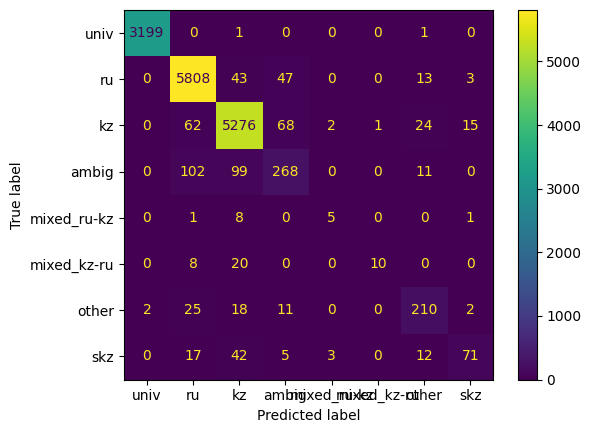

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test.explode(), pd.Series(y_pred_test).explode(), labels=crf.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=crf.classes_)
disp.plot()
plt.show()

Классы `kz`, `ru`, `univ` предсказываются с высокой точностью. `ambig` почти в половине случаев ошибочно принимается за `kz` и `ru`.
Определение тегов `skz` и `mixed_*` представляет для модели большие трудности, что неудивительно, так как природа токенов, принадлежащих этим классам, неоднозначна. Также свою роль сыграла малая частота, с которой эти теги встречались в датасете.

In [ ]:
# сохраняем модель
import pickle

filename = 'crf_model.pkl'
with open(filename, 'wb') as f:
    pickle.dump(crf, f)

# with open('crf_model.pkl', 'rb') as f:
    # loaded_crf = pickle.load(f)